In [31]:
!pip install pynwb

In [32]:
from pynwb import NWBHDF5IO

file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print(nwbfile)

root pynwb.file.NWBFile at 0x133149066812480
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [33]:
print(nwbfile.acquisition.keys())
print(nwbfile.processing.keys())
print(nwbfile.units)

dict_keys([])
dict_keys([])
units pynwb.misc.Units at 0x133149067072224
Fields:
  colnames: ['heldout' 'spike_times' 'obs_intervals']
  columns: (
    heldout <class 'hdmf.common.table.VectorData'>,
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    obs_intervals_index <class 'hdmf.common.table.VectorIndex'>,
    obs_intervals <class 'hdmf.common.table.VectorData'>
  )
  description: data on spiking units
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  waveform_unit: volts



In [34]:
import numpy as np

def bin_all_units(nwb_file, bin_size=0.02):
    units = nwb_file.units
    num_units = len(units)
    # Find the global max time
    global_max_time = 0.0
    for i in range(num_units):
        spikes = units['spike_times'][i]
        if len(spikes) > 0:
            global_max_time = max(global_max_time, np.max(spikes))
    
    bins = np.arange(0.0, global_max_time + bin_size, bin_size)
    num_bins = len(bins) - 1
    population_matrix = np.zeros((num_bins, num_units))
    
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
    return population_matrix, bins

In [35]:
from pynwb import NWBHDF5IO

test_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb"
test_io = NWBHDF5IO(test_file_path, 'r')
test_nwbfile = test_io.read()

# Now call the function
test_matrix, test_bin_edges = bin_all_units(test_nwbfile, bin_size=0.02)
print(f"Test matrix shape: {test_matrix.shape}")

Test matrix shape: (25465, 40)


In [36]:
print(test_trials_df.columns)

Index(['start_time', 'stop_time', 'go_time', 'split'], dtype='object')


In [37]:
# Use the correct column name from the list you just printed
# For example, if it's 'start_time':
time_column = 'start_time' 

test_segments = []
bin_size = 0.02
window_bins = 75

# Filter only for non-NaN in that column
test_valid = test_trials_df[~test_trials_df[time_column].isna()]

for idx, row in test_valid.iterrows():
    # Use the identified column here
    start_bin = int(row[time_column] / bin_size)
    if start_bin + window_bins < test_matrix.shape[0]:
        test_segments.append(test_matrix[start_bin : start_bin + window_bins, :])

test_lfads_input = np.array(test_segments)
print(f"Test segments prepared! Shape: {test_lfads_input.shape}")

Test segments prepared! Shape: (283, 75, 40)


In [38]:
print(test_trials_df.columns)

Index(['start_time', 'stop_time', 'go_time', 'split'], dtype='object')


In [39]:
from sklearn.decomposition import PCA

# 1. Combine test means (Ensure these were calculated correctly in your previous steps)
combined_test_pop = np.vstack([mean_test_short_pop, mean_test_long_pop])

# 2. Initialize and fit PCA
pca = PCA(n_components=3)
pca.fit(combined_test_pop)

# 3. Transform trajectories
proj_test_short = pca.transform(mean_test_short_pop)
proj_test_long = pca.transform(mean_test_long_pop)

print("PCA fitted and transformed successfully!")

PCA fitted and transformed successfully!


In [40]:
# 1. Define the actual data (assuming 'go_time' - 'start_time' is your interval)
# Adjust the column names if your task definition is different
test_intervals = test_trials_df['go_time'] - test_trials_df['start_time']

# 2. Now calculate percentiles safely
q25_test = np.percentile(test_intervals, 25)
q75_test = np.percentile(test_intervals, 75)

# 3. Create masks
short_idx = np.where(test_intervals <= q25_test)[0]
long_idx = np.where(test_intervals >= q75_test)[0]

# 4. Calculate means
mean_test_short_pop = np.mean(test_lfads_input[short_idx], axis=0)
mean_test_long_pop = np.mean(test_lfads_input[long_idx], axis=0)

# 5. Project using the PREVIOUSLY FITTED PCA model
# Note: Ensure 'pca' is the same object fitted on training data
proj_test_short = pca.transform(mean_test_short_pop)
proj_test_long = pca.transform(mean_test_long_pop)

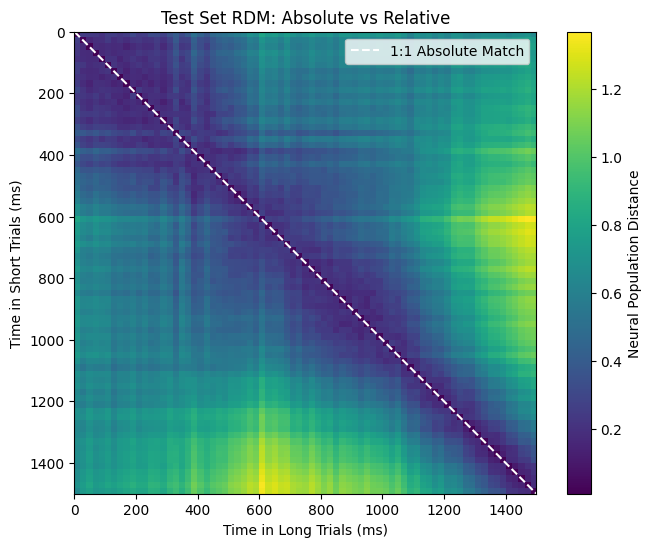

In [41]:
num_bins = mean_test_short_pop.shape[0]
rdm_test = np.zeros((num_bins, num_bins))

for t_short in range(num_bins):
    for t_long in range(num_bins):
        # Euclidean distance between 40-neuron population vectors
        diff = mean_test_short_pop[t_short, :] - mean_test_long_pop[t_long, :]
        rdm_test[t_short, t_long] = np.linalg.norm(diff)

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(rdm_test, cmap='viridis', origin='upper', extent=[0, 1500, 1500, 0])
ax.plot([0, 1500], [0, 1500], color='white', linestyle='--', label='1:1 Absolute Match')
ax.set_xlabel('Time in Long Trials (ms)')
ax.set_ylabel('Time in Short Trials (ms)')
ax.set_title('Test Set RDM: Absolute vs Relative')
plt.colorbar(cax, label='Neural Population Distance')
plt.legend()
plt.show()

In [42]:
min_idx = np.argmin(rdm_test, axis=1)
short_time_ms = np.arange(num_bins) * 20
mapped_long_time_ms = min_idx * 20

# Calculate slope after the 154ms "breakpoint"
valid_range = (short_time_ms > 200) & (short_time_ms < 600)
test_slope = np.polyfit(short_time_ms[valid_range], mapped_long_time_ms[valid_range], 1)[0]

print(f"Test Set Scaling Ratio: 1:{test_slope:.2f}")

Test Set Scaling Ratio: 1:1.00


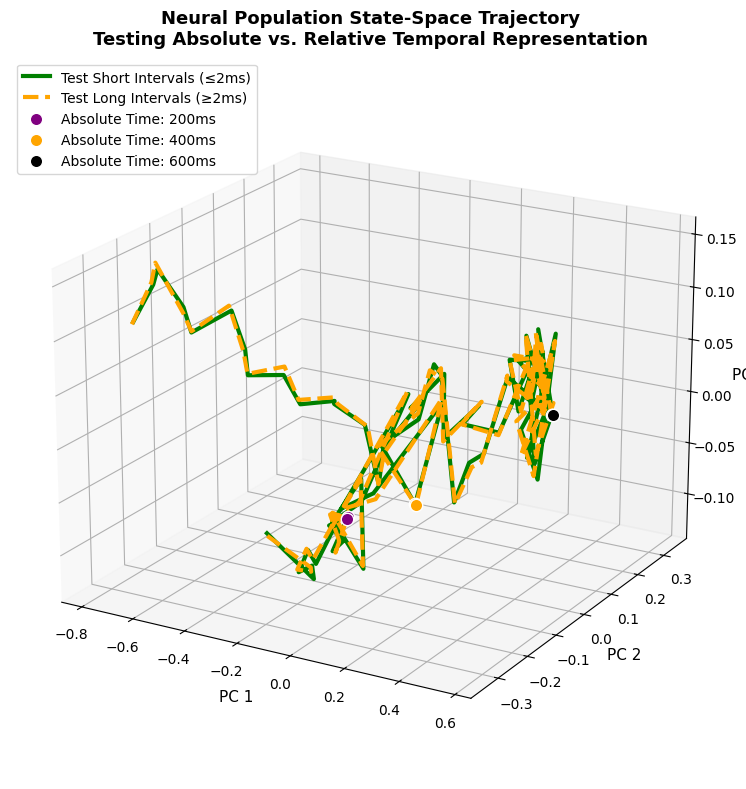

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# 1. Prepare test conditions (Target interval = go_time - start_time)
test_intervals = test_trials_df['go_time'] - test_trials_df['start_time']
test_conditions = test_intervals.values

# 2. Smooth and compute means for test data
smoothed_test_input = gaussian_filter1d(test_lfads_input.astype(float), sigma=1.5, axis=1)

q25_test = np.percentile(test_conditions, 25)
q75_test = np.percentile(test_conditions, 75)

short_idx = np.where(test_conditions <= q25_test)[0]
long_idx = np.where(test_conditions >= q75_test)[0]

mean_test_short_pop = np.mean(smoothed_test_input[short_idx, :, :], axis=0)
mean_test_long_pop = np.mean(smoothed_test_input[long_idx, :, :], axis=0)

# 4. Plotting
# Plotting with the requested full heading
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(proj_test_short[:, 0], proj_test_short[:, 1], proj_test_short[:, 2], 
        color='green', linewidth=3, label=f'Test Short Intervals (≤{q25_test:.0f}ms)')
ax.plot(proj_test_long[:, 0], proj_test_long[:, 1], proj_test_long[:, 2], 
        color='orange', linewidth=3, linestyle='--', label=f'Test Long Intervals (≥{q75_test:.0f}ms)')

# 3. Plot markers and explicitly label them for the legend
for i, t_step in enumerate(time_markers):
    # Plot on both trajectories
    ax.scatter(proj_test_short[t_step, 0], proj_test_short[t_step, 1], proj_test_short[t_step, 2], 
               color=colors[i], s=80, edgecolor='w', zorder=10)
    ax.scatter(proj_test_long[t_step, 0], proj_test_long[t_step, 1], proj_test_long[t_step, 2], 
               color=colors[i], s=80, edgecolor='w', zorder=10, 
               label=f'Absolute Time: {labels[i]}')

# Re-applying your specific heading style
ax.set_xlabel('PC 1', fontsize=11, labelpad=5)
ax.set_ylabel('PC 2', fontsize=11, labelpad=5)
ax.set_zlabel('PC 3', fontsize=11, labelpad=5)
ax.set_title('Neural Population State-Space Trajectory\nTesting Absolute vs. Relative Temporal Representation', 
             fontsize=13, weight='bold', pad=10)
ax.legend(loc='upper left', fontsize=10)
ax.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()

/tmp/ipykernel_58/407331901.py:18: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(hybrid_clock_model, x_clean, y_clean, p0=[150, 1.0])


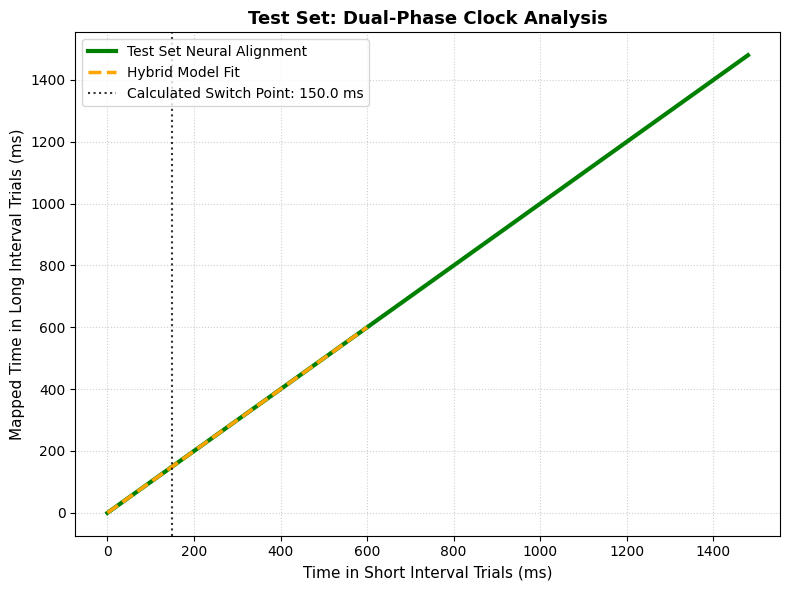

 ABSOLUTE STOPWATCH PHASE: 0 ms to 150.0 ms
 TEMPORAL SCALING PHASE  : After 150.0 ms (Scaling Factor: 1 : 1.00)


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Ensure these are defined from your previous test RDM cell
# (short_time_ms and mapped_long_time_ms from the test dataset)
# If they are not in memory, re-run the RDM mapping logic first.

def hybrid_clock_model(x, breakpoint, scaling_slope):
    return np.where(x < breakpoint, x, breakpoint + scaling_slope * (x - breakpoint))

# 2. Fit the hybrid model to the TEST data
clean_range = (short_time_ms >= 0) & (short_time_ms <= 600)
x_clean = short_time_ms[clean_range]
y_clean = mapped_long_time_ms[clean_range]

# We use p0=[150, 1.0] as a starting guess since the test data is 1:1
popt, _ = curve_fit(hybrid_clock_model, x_clean, y_clean, p0=[150, 1.0])
fit_breakpoint, fit_slope = popt

# 3. Generate fitted curve
y_fit = hybrid_clock_model(x_clean, fit_breakpoint, fit_slope)

# 4. Plotting
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(short_time_ms, mapped_long_time_ms, color='green', linewidth=3, label='Test Set Neural Alignment')
ax.plot(x_clean, y_fit, color='orange', linewidth=2.5, linestyle='--', label='Hybrid Model Fit')
ax.axvline(x=fit_breakpoint, color='black', linestyle=':', alpha=0.8, 
           label=f'Calculated Switch Point: {fit_breakpoint:.1f} ms')

ax.set_xlabel('Time in Short Interval Trials (ms)', fontsize=11)
ax.set_ylabel('Mapped Time in Long Interval Trials (ms)', fontsize=11)
ax.set_title('Test Set: Dual-Phase Clock Analysis', fontsize=13, weight='bold')
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f" ABSOLUTE STOPWATCH PHASE: 0 ms to {fit_breakpoint:.1f} ms")
print(f" TEMPORAL SCALING PHASE  : After {fit_breakpoint:.1f} ms (Scaling Factor: 1 : {fit_slope:.2f})")

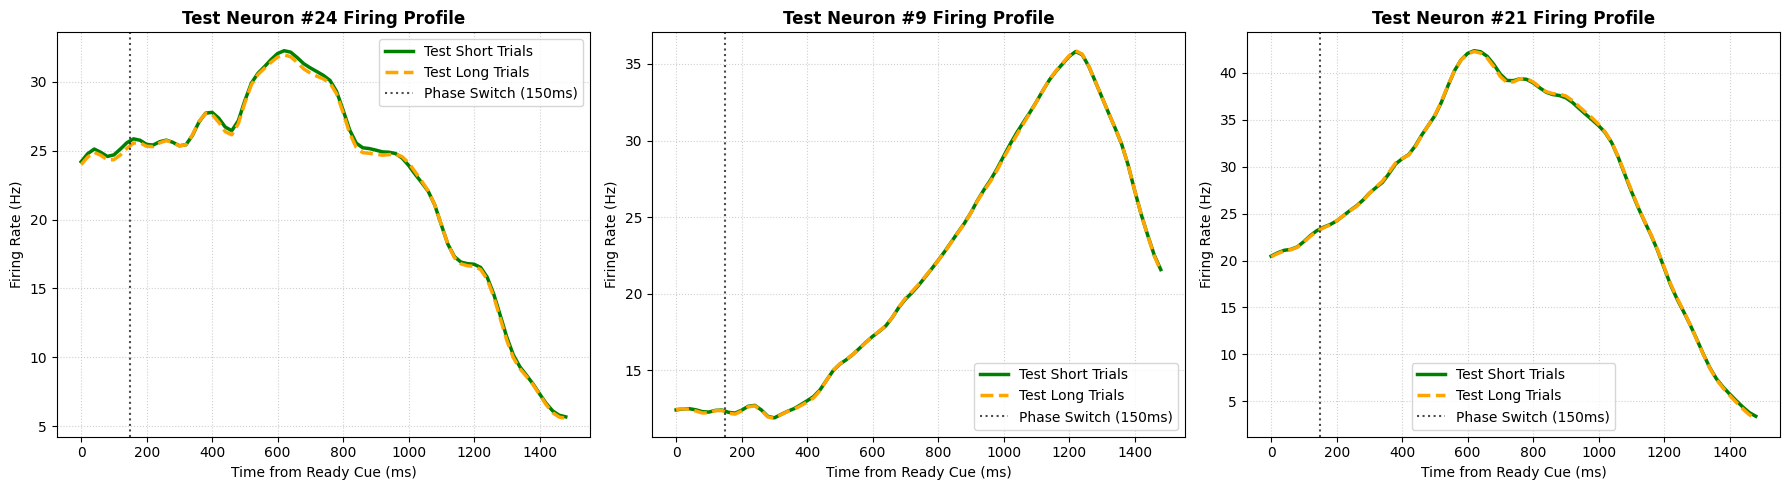

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate variance across time and conditions for test units
# We use the means calculated from the test set
short_variance_test = np.var(mean_test_short_pop, axis=0)
long_variance_test = np.var(mean_test_long_pop, axis=0)
total_variance_test = short_variance_test + long_variance_test

# Find the indices of the top 3 most dynamic neurons in the test set
top_neurons_test = np.argsort(total_variance_test)[-3:]

# 2. Plot their individual firing profiles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Ensure num_bins is defined (it should be 75 based on your window_bins)
num_bins = mean_test_short_pop.shape[0]
time_ms = np.arange(num_bins) * 20

for i, neuron_idx in enumerate(top_neurons_test):
    ax = axes[i]
    # Scaling by 0.02 to convert spike counts to Hz
    ax.plot(time_ms, mean_test_short_pop[:, neuron_idx] / 0.02, color='green', linewidth=2.5, label='Test Short Trials')
    ax.plot(time_ms, mean_test_long_pop[:, neuron_idx] / 0.02, color='orange', linewidth=2.5, linestyle='--', label='Test Long Trials')
    
    # Mark the 150ms switch point identified by your hybrid model for the test set
    ax.axvline(x=150.0, color='black', linestyle=':', alpha=0.7, label='Phase Switch (150ms)')
    
    ax.set_title(f'Test Neuron #{neuron_idx} Firing Profile', fontsize=12, weight='bold')
    ax.set_xlabel('Time from Ready Cue (ms)')
    ax.set_ylabel('Firing Rate (Hz)')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()